<a href="https://colab.research.google.com/github/akshatamadavi/advanced_customization/blob/main/PyTorch_Regularization_Augmentation_Masterclass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔥 PyTorch Masterclass: Regularization, Augmentation & Generalization

**A/B Testing Every Technique — Line-by-Line Video Walkthrough**

## 📋 Table of Contents
1. Setup & Imports
2. L1 / L2 Regularization (A/B Test)
3. Dropout (A/B Test)
4. Early Stopping (A/B Test)
5. Monte Carlo Dropout
6. Weight Initializations
7. Batch Normalization (A/B Test)
8. Custom Dropout & Custom Regularization
9. Callbacks & TensorBoard
10. Optuna — Hyperparameter Search (≈ KerasTuner for PyTorch)
11. torchvision Data Augmentation (≈ KerasCV)
12. **Data Augmentation & Classification Tasks**
    - 12a. Image Classification
    - 12b. Video Classification
    - 12c. Text / NLP (nlpaug)
    - 12d. Time Series
    - 12e. Tabular Data
    - 12f. Speech / Audio
    - 12g. Document Images (OCR)


## 1. 🔧 Setup & Imports

In [1]:
# ── Install extra libraries ──────────────────────────────────────────────────
!pip install -q optuna nlpaug librosa torchvision torchaudio
!pip install -q pytesseract Pillow imbalanced-learn
!apt-get install -q tesseract-ocr

import os, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from copy import deepcopy

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.utils.tensorboard import SummaryWriter

import torchvision
import torchvision.transforms as T
import torchvision.transforms.v2 as Tv2   # new API (torchvision ≥ 0.15)
from torchvision.datasets import CIFAR10

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {DEVICE}')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if DEVICE == 'cuda':
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

# ── Shared helpers ───────────────────────────────────────────────────────────
def plot_histories(histories: dict, title=''):
    """Plot train/val loss and accuracy for multiple runs."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for name, rec in histories.items():
        axes[0].plot(rec['train_loss'], label=f'{name} train')
        axes[0].plot(rec['val_loss'],   label=f'{name} val', linestyle='--')
        axes[1].plot(rec['train_acc'],  label=f'{name} train')
        axes[1].plot(rec['val_acc'],    label=f'{name} val',  linestyle='--')
    for ax, t in zip(axes, ['Loss', 'Accuracy']):
        ax.set_title(f'{title} — {t}'); ax.legend(); ax.grid(True)
    plt.tight_layout(); plt.show()


def train_epoch(model, loader, optimizer, criterion, device, l1_lambda=0., l2_lambda=0.):
    """One training epoch with optional manual L1/L2."""
    model.train()
    total_loss, correct, n = 0., 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(X)
        loss = criterion(out, y)

        # ── Manual L1 / L2 regularization ─────────────────────────────────
        if l1_lambda > 0:
            l1 = sum(p.abs().sum() for p in model.parameters())
            loss = loss + l1_lambda * l1
        if l2_lambda > 0:
            l2 = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l2_lambda * l2

        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct    += (out.argmax(1) == y).sum().item()
        n          += len(y)
    return total_loss / n, correct / n


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, n = 0., 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        out   = model(X)
        loss  = criterion(out, y)
        total_loss += loss.item() * len(y)
        correct    += (out.argmax(1) == y).sum().item()
        n          += len(y)
    return total_loss / n, correct / n


def full_train(model, train_loader, val_loader, epochs=20,
               lr=1e-3, l1=0., l2=0., patience=None, device=DEVICE):
    """Complete training loop with optional early stopping."""
    # NOTE: PyTorch weight_decay in Adam = L2 reg (identical math)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=l2)
    criterion = nn.CrossEntropyLoss()
    rec = defaultdict(list)

    best_val, best_state, wait = float('inf'), None, 0

    for epoch in range(epochs):
        tl, ta = train_epoch(model, train_loader, optimizer, criterion,
                             device, l1_lambda=l1)
        vl, va = eval_epoch(model, val_loader, criterion, device)
        rec['train_loss'].append(tl); rec['val_loss'].append(vl)
        rec['train_acc'].append(ta);  rec['val_acc'].append(va)

        # ── Early Stopping logic ───────────────────────────────────────────
        if patience is not None:
            if vl < best_val - 1e-4:
                best_val   = vl
                best_state = deepcopy(model.state_dict())
                wait       = 0
            else:
                wait += 1
                if wait >= patience:
                    model.load_state_dict(best_state)  # restore best
                    print(f'  EarlyStopping at epoch {epoch+1}')
                    break

    return dict(rec)


def get_cifar_loaders(batch_size=256, n_train=10000):
    tf  = T.Compose([T.ToTensor()])
    tr  = CIFAR10(root='/tmp/cifar', train=True,  download=True, transform=tf)
    te  = CIFAR10(root='/tmp/cifar', train=False, download=True, transform=tf)
    tr  = torch.utils.data.Subset(tr, range(n_train))
    te  = torch.utils.data.Subset(te, range(2000))
    return (DataLoader(tr, batch_size=batch_size, shuffle=True,  num_workers=2),
            DataLoader(te, batch_size=batch_size, shuffle=False, num_workers=2))

print('✅ Setup complete')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 24.0 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
PyTorch version : 2.10.0+cu128
Device          : cuda
✅ Setup complete


## 2. ⚖️ L1 / L2 Regularization — A/B Test

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# In PyTorch:
#   L2 (weight decay) → built into optimizers via `weight_decay` param
#   L1 → must be added manually in the training loop (see train_epoch above)
# ─────────────────────────────────────────────────────────────────────────────

class DenseNet(nn.Module):
    """Simple 3-layer MLP for CIFAR-10 (flattened input)."""
    def __init__(self, dropout_rate=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3072, 512), nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),  nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),  nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)

train_loader, val_loader = get_cifar_loaders()

configs = [
    ('No Reg',  0.,    0.),
    ('L1',      1e-5,  0.),
    ('L2',      0.,    1e-4),   # weight_decay in Adam
    ('L1+L2',   1e-5,  1e-4),
]

histories_reg = {}
for name, l1, l2 in configs:
    print(f'Training: {name}')
    model = DenseNet().to(DEVICE)
    rec   = full_train(model, train_loader, val_loader,
                       epochs=20, l1=l1, l2=l2)
    histories_reg[name] = rec

plot_histories(histories_reg, title='L1/L2 A/B Test')

print('\n📊 Best val accuracy:')
for name, rec in histories_reg.items():
    print(f'  {name:<10}: {max(rec["val_acc"]):.4f}')

100%|██████████| 170M/170M [00:03<00:00, 44.0MB/s]


Training: No Reg
Training: L1


## 3. 🎲 Dropout — A/B Test

Training: No Dropout
Training: Drop 0.2
Training: Drop 0.4
Training: Drop 0.6


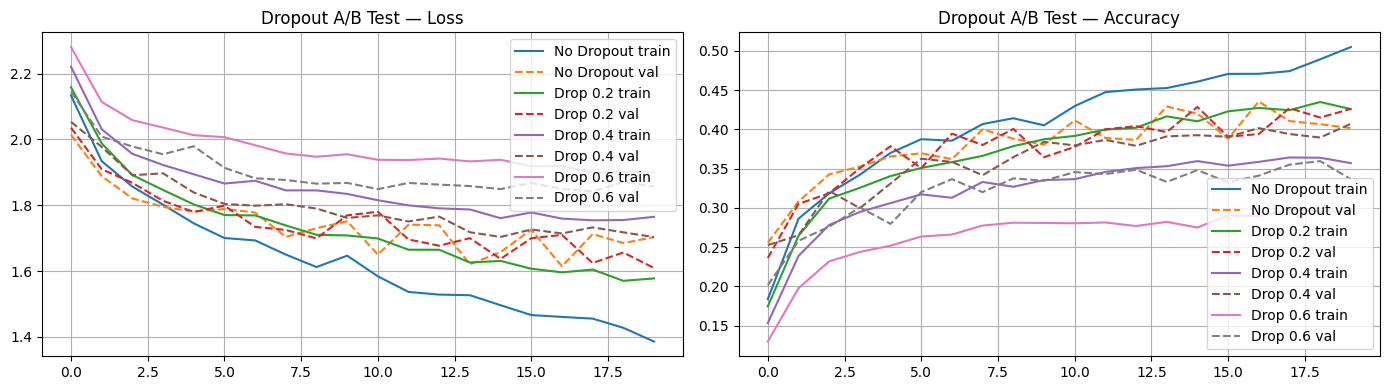


💡 model.train() enables dropout; model.eval() disables it


In [ ]:
# ── nn.Dropout(p) zeroes units with probability p during model.train() ─────
# During model.eval() → dropout is disabled automatically

drop_configs = [(0.0, 'No Dropout'), (0.2, 'Drop 0.2'),
                (0.4, 'Drop 0.4'),   (0.6, 'Drop 0.6')]

histories_drop = {}
for rate, name in drop_configs:
    print(f'Training: {name}')
    model = DenseNet(dropout_rate=rate).to(DEVICE)
    rec   = full_train(model, train_loader, val_loader, epochs=20)
    histories_drop[name] = rec

plot_histories(histories_drop, title='Dropout A/B Test')

# ── Key: model.train() vs model.eval() ────────────────────────────────────
model = DenseNet(0.3).to(DEVICE)
model.train()  # Dropout ON  → training
model.eval()   # Dropout OFF → inference
print('\n💡 model.train() enables dropout; model.eval() disables it')

## 4. 🛑 Early Stopping — A/B Test

Training WITHOUT early stopping (80 epochs)...

Training WITH early stopping (patience=5)...
  EarlyStopping at epoch 27

No ES   → 80 epochs trained, best val_acc=0.4575
With ES → 27 epochs trained, best val_acc=0.4490


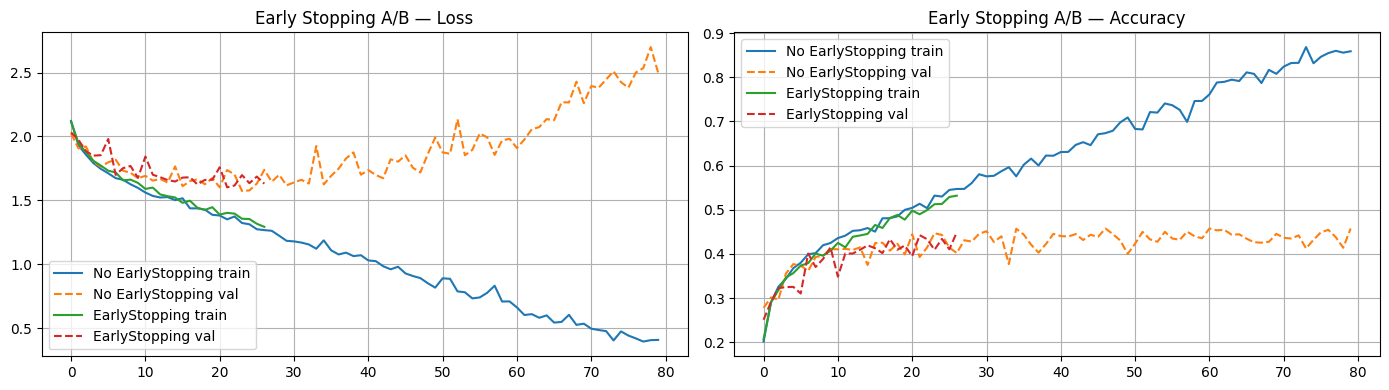

In [ ]:
# ── Early stopping is implemented inside full_train (see setup cell) ─────────
# patience=None → train all epochs (can overfit)
# patience=5    → stop if val_loss doesn't improve for 5 epochs + restore best

print('Training WITHOUT early stopping (80 epochs)...')
m_no_es = DenseNet().to(DEVICE)
rec_no_es = full_train(m_no_es, train_loader, val_loader,
                       epochs=80, patience=None)

print('\nTraining WITH early stopping (patience=5)...')
m_es = DenseNet().to(DEVICE)
rec_es = full_train(m_es, train_loader, val_loader,
                    epochs=80, patience=5)

print(f'\nNo ES   → {len(rec_no_es["val_loss"])} epochs trained, '
      f'best val_acc={max(rec_no_es["val_acc"]):.4f}')
print(f'With ES → {len(rec_es["val_loss"])} epochs trained, '
      f'best val_acc={max(rec_es["val_acc"]):.4f}')

plot_histories({'No EarlyStopping': rec_no_es, 'EarlyStopping': rec_es},
               title='Early Stopping A/B')

## 5. 🎲 Monte Carlo Dropout — Uncertainty Estimation

Mean predictions (first 3 samples):
[[0.113 0.061 0.142 0.156 0.07  0.15  0.066 0.042 0.168 0.031]
 [0.086 0.259 0.007 0.003 0.002 0.001 0.    0.005 0.42  0.217]
 [0.173 0.079 0.012 0.002 0.003 0.002 0.    0.006 0.664 0.059]]

Uncertainty (std across forward passes):
[[0.0436 0.0304 0.0407 0.0534 0.0233 0.0566 0.0249 0.0107 0.0724 0.0125]
 [0.0304 0.0677 0.005  0.0024 0.0017 0.001  0.0005 0.0034 0.1061 0.0929]
 [0.0369 0.0396 0.0083 0.0024 0.0022 0.0026 0.0006 0.0043 0.0828 0.0275]]


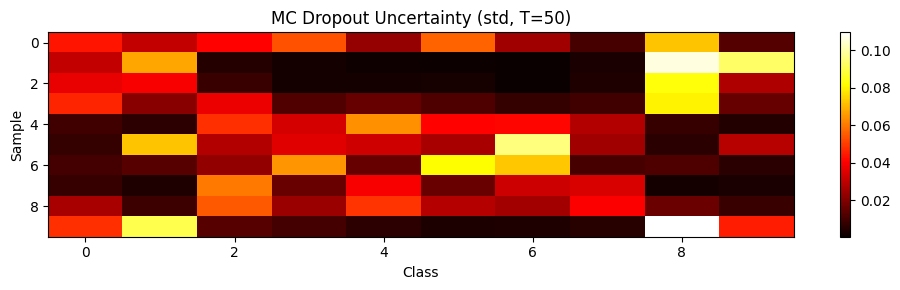

In [ ]:
# ── MC Dropout: call model.train() at test time to keep dropout active ────────

class MCDropoutNet(nn.Module):
    """Same as DenseNet but MCDropout is always ON."""
    def __init__(self, rate=0.3):
        super().__init__()
        self.rate = rate
        self.fc1 = nn.Linear(3072, 512)
        self.fc2 = nn.Linear(512,  256)
        self.fc3 = nn.Linear(256,  128)
        self.fc4 = nn.Linear(128,  10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=self.rate, training=True)  # always ON
        x = F.relu(self.fc2(x))
        x = F.dropout(x, p=self.rate, training=True)
        x = F.relu(self.fc3(x))
        return self.fc4(x)


mc_model = MCDropoutNet(0.3).to(DEVICE)
full_train(mc_model, train_loader, val_loader, epochs=10)

# ── MC inference ───────────────────────────────────────────────────────────
T = 50  # forward passes
sample_batch = next(iter(val_loader))
sample_X = sample_batch[0][:10].to(DEVICE)

mc_model.eval()  # eval mode but F.dropout(training=True) bypasses this
with torch.no_grad():
    mc_preds = torch.stack([
        F.softmax(mc_model(sample_X), dim=-1)
        for _ in range(T)
    ])  # shape: (T, 10, 10)

mean_pred   = mc_preds.mean(0).cpu().numpy()
uncertainty = mc_preds.std(0).cpu().numpy()

print('Mean predictions (first 3 samples):')
print(mean_pred[:3].round(3))
print('\nUncertainty (std across forward passes):')
print(uncertainty[:3].round(4))

fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(uncertainty, aspect='auto', cmap='hot')
ax.set_xlabel('Class'); ax.set_ylabel('Sample')
ax.set_title('MC Dropout Uncertainty (std, T=50)')
plt.colorbar(im); plt.tight_layout(); plt.show()

## 6. 🏁 Weight Initializations — When to Use What

Training: kaiming_uniform
Training: kaiming_normal
Training: xavier_uniform
Training: xavier_normal
Training: orthogonal
Training: normal_0.01


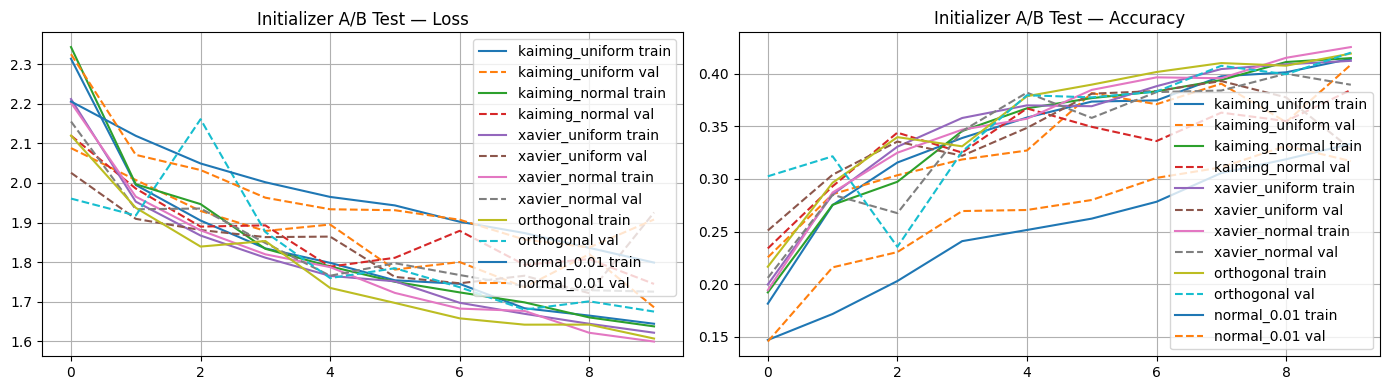


First-epoch training loss:
  kaiming_uniform   : 2.3141
  kaiming_normal    : 2.3436
  xavier_uniform    : 2.2122
  xavier_normal     : 2.2029
  orthogonal        : 2.1199
  normal_0.01       : 2.2060


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PyTorch init functions (torch.nn.init):
#  kaiming_uniform_  → He init (uniform)  → best for ReLU
#  kaiming_normal_   → He init (normal)   → best for ReLU
#  xavier_uniform_   → Glorot (uniform)   → best for tanh/sigmoid
#  xavier_normal_    → Glorot (normal)
#  orthogonal_       → orthogonal matrix  → RNNs, preserves gradients
#  zeros_ / ones_    → only for bias!
#  normal_           → standard normal (often too large)
#  sparse_           → sparse init
# ─────────────────────────────────────────────────────────────────────────────

INIT_FNS = {
    'kaiming_uniform': lambda w: nn.init.kaiming_uniform_(w, nonlinearity='relu'),
    'kaiming_normal' : lambda w: nn.init.kaiming_normal_(w,  nonlinearity='relu'),
    'xavier_uniform' : nn.init.xavier_uniform_,
    'xavier_normal'  : nn.init.xavier_normal_,
    'orthogonal'     : nn.init.orthogonal_,
    'normal_0.01'    : lambda w: nn.init.normal_(w, std=0.01),
}

def build_initialized_model(init_fn):
    model = DenseNet().to(DEVICE)
    # Apply init to all Linear weight tensors
    for module in model.modules():
        if isinstance(module, nn.Linear):
            init_fn(module.weight)
            nn.init.zeros_(module.bias)   # bias always zero-init
    return model

histories_init = {}
for name, fn in INIT_FNS.items():
    print(f'Training: {name}')
    model = build_initialized_model(fn)
    rec   = full_train(model, train_loader, val_loader, epochs=10)
    histories_init[name] = rec

plot_histories(histories_init, title='Initializer A/B Test')

print('\nFirst-epoch training loss:')
for name, rec in histories_init.items():
    print(f'  {name:<18}: {rec["train_loss"][0]:.4f}')

## 7. 📐 Batch Normalization — A/B Test

Training: No BN
Training: BN before act
Training: BN after act


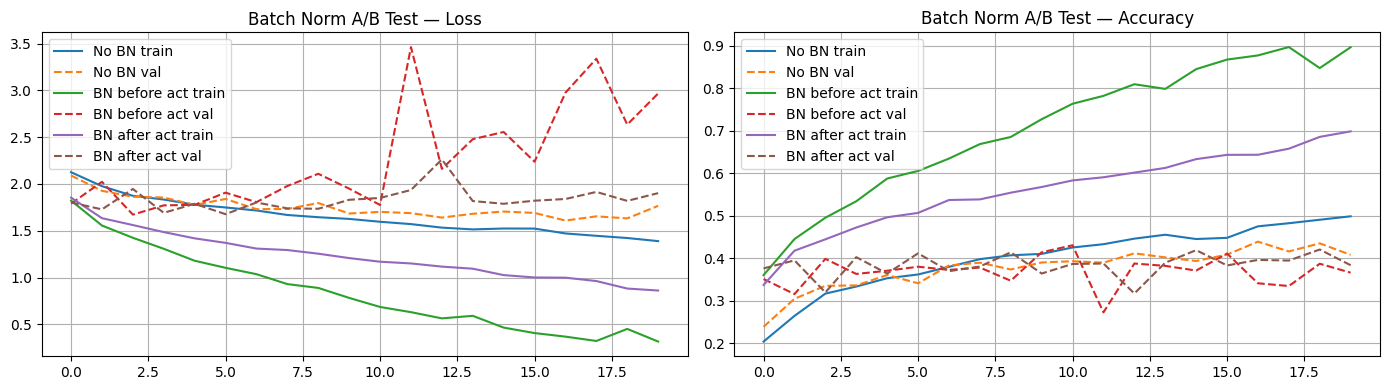

In [ ]:
# ── BatchNorm1d for fully-connected, BatchNorm2d for conv layers ─────────────

class DenseNetBN(nn.Module):
    def __init__(self, use_bn=False, bn_before_act=True):
        super().__init__()
        layers_ = [nn.Flatten()]
        dims = [(3072, 512), (512, 256), (256, 128)]

        for in_d, out_d in dims:
            layers_.append(nn.Linear(in_d, out_d,
                                     bias=(not use_bn)))  # bias=False when BN follows
            if use_bn and bn_before_act:
                # BN before activation (original Ioffe & Szegedy 2015)
                layers_.append(nn.BatchNorm1d(out_d))
                layers_.append(nn.ReLU())
            elif use_bn and not bn_before_act:
                # BN after activation (common modern practice)
                layers_.append(nn.ReLU())
                layers_.append(nn.BatchNorm1d(out_d))
            else:
                layers_.append(nn.ReLU())

        layers_.append(nn.Linear(128, 10))
        self.net = nn.Sequential(*layers_)

    def forward(self, x):
        return self.net(x)

bn_configs = [
    (False, True,  'No BN'),
    (True,  True,  'BN before act'),
    (True,  False, 'BN after act'),
]

histories_bn = {}
for use_bn, before, name in bn_configs:
    print(f'Training: {name}')
    model = DenseNetBN(use_bn=use_bn, bn_before_act=before).to(DEVICE)
    rec   = full_train(model, train_loader, val_loader, epochs=20)
    histories_bn[name] = rec

plot_histories(histories_bn, title='Batch Norm A/B Test')

## 8. 🔨 Custom Dropout & Custom Regularization

In [ ]:
# ── 8a. Custom Dropout Variants ───────────────────────────────────────────────

class GaussianDropout(nn.Module):
    """Multiplicative Gaussian noise dropout.
    σ² = rate/(1-rate); more smooth than Bernoulli.
    """
    def __init__(self, rate=0.3):
        super().__init__()
        self.rate = rate

    def forward(self, x):
        if self.training:
            std   = (self.rate / (1. - self.rate)) ** 0.5
            noise = torch.randn_like(x) * std + 1.0   # mult noise centred at 1
            return x * noise
        return x


class DropBlock1D(nn.Module):
    """DropBlock: drops contiguous blocks (better for structured data).
    Ref: Ghiasi et al. 2018.
    """
    def __init__(self, block_size=3, drop_prob=0.1):
        super().__init__()
        self.block_size = block_size
        self.drop_prob  = drop_prob

    def forward(self, x):
        if not self.training or self.drop_prob == 0:
            return x
        # x: (batch, channels)  — 1-D version for FC layers
        mask  = (torch.rand_like(x) > self.drop_prob).float()
        # Erode: if any neighbour is masked, mask the unit
        mask  = F.avg_pool1d(
            mask.unsqueeze(1), self.block_size, stride=1,
            padding=self.block_size//2
        ).squeeze(1)
        mask  = (mask == 1.).float()
        return x * mask


class StochasticDepth(nn.Module):
    """Randomly skip residual branches during training (Huang et al. 2016).
    Commonly used in ResNets and Vision Transformers.
    """
    def __init__(self, drop_prob=0.2):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x, skip):
        if self.training and torch.rand(1).item() < self.drop_prob:
            return skip    # completely skip residual branch
        return x + skip


# ── 8b. Custom Regularization as a Loss Term ──────────────────────────────────

class OrthogonalRegularizer:
    """Penalty to keep weight columns orthogonal."""
    def __init__(self, factor=1e-4):
        self.factor = factor

    def __call__(self, weight):
        w   = weight.view(weight.shape[0], -1)
        wwt = torch.mm(w.T, w)
        I   = torch.eye(wwt.shape[0], device=weight.device)
        return self.factor * (wwt - I).norm()


class MaxNormConstraint:
    """Clip weight norms to max_val after each gradient step."""
    def __init__(self, max_val=2.0):
        self.max_val = max_val

    def apply(self, model):
        with torch.no_grad():
            for p in model.parameters():
                norm = p.data.norm(dim=0, keepdim=True)
                desired = norm.clamp(max=self.max_val)
                p.data.mul_(desired / (norm + 1e-8))


# ── Demo model ────────────────────────────────────────────────────────────────
class CustomRegModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3072, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)
        self.gdrop  = GaussianDropout(0.3)
        self.db     = DropBlock1D(block_size=3, drop_prob=0.1)
        self.orth_reg = OrthogonalRegularizer(1e-5)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.gdrop(x)
        x = F.relu(self.fc2(x))
        x = self.db(x)
        return self.fc3(x)

    def reg_loss(self):
        """Sum all custom regularization terms."""
        return self.orth_reg(self.fc1.weight) + self.orth_reg(self.fc2.weight)


# Train with custom regularization
custom_model  = CustomRegModel().to(DEVICE)
optimizer_c   = optim.Adam(custom_model.parameters(), lr=1e-3)
criterion_c   = nn.CrossEntropyLoss()
max_norm      = MaxNormConstraint(max_val=3.0)

cust_history  = defaultdict(list)
for epoch in range(10):
    custom_model.train()
    for X, y in train_loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer_c.zero_grad()
        out  = custom_model(X)
        loss = criterion_c(out, y) + custom_model.reg_loss()  # add custom reg
        loss.backward()
        optimizer_c.step()
        max_norm.apply(custom_model)   # post-step constraint

    vl, va = eval_epoch(custom_model, val_loader, criterion_c, DEVICE)
    cust_history['val_loss'].append(vl)
    cust_history['val_acc'].append(va)

print(f'Custom model best val_acc: {max(cust_history["val_acc"]):.4f}')

Custom model best val_acc: 0.3890


## 9. 📡 TensorBoard & Training Callbacks (PyTorch-style)

In [ ]:
import datetime
from torch.utils.tensorboard import SummaryWriter

LOG_DIR = '/tmp/tb_logs/' + datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
writer  = SummaryWriter(LOG_DIR)

# ── PyTorch-style callback pattern via hooks ───────────────────────────────────

class LRSchedulerCallback:
    """Reduce LR on plateau."""
    def __init__(self, optimizer, patience=3, factor=0.5):
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, patience=patience, factor=factor, verbose=True
        )
    def step(self, val_loss):
        self.scheduler.step(val_loss)


class WarmUpScheduler:
    """Linear warmup then cosine annealing."""
    def __init__(self, optimizer, warmup_epochs=3, total_epochs=20):
        def lr_lambda(epoch):
            if epoch < warmup_epochs:
                return float(epoch + 1) / warmup_epochs
            # cosine decay after warmup
            progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
            return 0.5 * (1 + np.cos(np.pi * progress))
        self.scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    def step(self):
        self.scheduler.step()


class ModelCheckpoint:
    """Save model when val_loss improves."""
    def __init__(self, path='/tmp/best_pt_model.pth'):
        self.path     = path
        self.best_val = float('inf')

    def step(self, val_loss, model):
        if val_loss < self.best_val:
            self.best_val = val_loss
            torch.save(model.state_dict(), self.path)
            print(f'  ✅ Checkpoint saved (val_loss={val_loss:.4f})')


# ── Training loop with all callbacks + TensorBoard ─────────────────────────
model_cb  = DenseNetBN(use_bn=True).to(DEVICE)
optim_cb  = optim.Adam(model_cb.parameters(), lr=1e-3)
crit_cb   = nn.CrossEntropyLoss()

lr_cb     = LRSchedulerCallback(optim_cb, patience=3)
warmup_cb = WarmUpScheduler(optim_cb, warmup_epochs=3, total_epochs=25)
ckpt_cb   = ModelCheckpoint()

for epoch in range(25):
    tl, ta = train_epoch(model_cb, train_loader, optim_cb, crit_cb, DEVICE)
    vl, va = eval_epoch(model_cb,  val_loader,   crit_cb, DEVICE)

    # ── TensorBoard logging ────────────────────────────────────────────────
    writer.add_scalar('Loss/train',     tl, epoch)
    writer.add_scalar('Loss/val',       vl, epoch)
    writer.add_scalar('Accuracy/train', ta, epoch)
    writer.add_scalar('Accuracy/val',   va, epoch)
    writer.add_scalar('LR', optim_cb.param_groups[0]['lr'], epoch)

    # Log weight histograms every 5 epochs
    if epoch % 5 == 0:
        for name_, param in model_cb.named_parameters():
            writer.add_histogram(name_, param, epoch)
            if param.grad is not None:
                writer.add_histogram(f'{name_}.grad', param.grad, epoch)

    # ── Callbacks ──────────────────────────────────────────────────────────
    lr_cb.step(vl)
    warmup_cb.step()
    ckpt_cb.step(vl, model_cb)

    if epoch % 5 == 0:
        print(f'Epoch {epoch:2d} | loss={tl:.4f} | val_loss={vl:.4f} | val_acc={va:.4f}')

writer.flush()
writer.close()
print(f'\nTensorBoard logs at: {LOG_DIR}')

%load_ext tensorboard
%tensorboard --logdir /tmp/tb_logs

TypeError: ReduceLROnPlateau.__init__() got an unexpected keyword argument 'verbose'

## 10. 🔍 Optuna — Automated Hyperparameter Search

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Objective function: defines the search space ──────────────────────────────
def objective(trial):
    # ── Search space ──────────────────────────────────────────────────────
    n_layers  = trial.suggest_int('n_layers', 1, 4)
    use_bn    = trial.suggest_categorical('use_bn', [True, False])
    dropout   = trial.suggest_float('dropout', 0.0, 0.5)
    lr        = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    l2        = trial.suggest_float('l2', 1e-6, 1e-3, log=True)

    # ── Build model from trial params ─────────────────────────────────────
    layer_list = [nn.Flatten()]
    in_dim = 3072
    for i in range(n_layers):
        out_dim = trial.suggest_int(f'units_{i}', 64, 512, step=64)
        layer_list.append(nn.Linear(in_dim, out_dim))
        if use_bn:
            layer_list.append(nn.BatchNorm1d(out_dim))
        layer_list.append(nn.ReLU())
        layer_list.append(nn.Dropout(dropout))
        in_dim = out_dim
    layer_list.append(nn.Linear(in_dim, 10))

    model  = nn.Sequential(*layer_list).to(DEVICE)
    optim_ = optim.Adam(model.parameters(), lr=lr, weight_decay=l2)
    crit_  = nn.CrossEntropyLoss()

    # ── Short training (fast eval) ─────────────────────────────────────────
    for epoch in range(8):
        train_epoch(model, train_loader, optim_, crit_, DEVICE)

    _, val_acc = eval_epoch(model, val_loader, crit_, DEVICE)
    return val_acc   # maximise


# ── Run study ─────────────────────────────────────────────────────────────────
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),       # Bayesian (Tree-Parzen)
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3)  # kill bad trials early
)
study.optimize(objective, n_trials=15, show_progress_bar=True)

print('\n🏆 Best trial:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')
print(f'  val_accuracy: {study.best_value:.4f}')

# ── Visualise search ──────────────────────────────────────────────────────────
try:
    import optuna.visualization as ov
    fig = ov.plot_optimization_history(study)
    fig.show()
    fig2 = ov.plot_param_importances(study)
    fig2.show()
except Exception:
    pass  # plotly may not be installed

print('\n--- Equivalent samplers ---')
print('optuna.samplers.RandomSampler()    → like Keras RandomSearch')
print('optuna.samplers.CmaEsSampler()     → evolution-based')
print('optuna.samplers.NSGAIISampler()    → multi-objective')

## 11. 🖼️ torchvision Data Augmentation Pipeline (≈ KerasCV)

In [ ]:
# ── torchvision.transforms.v2 — new GPU-compatible, composable API ─────────────
import torchvision.transforms.v2 as Tv2

# ── Full augmentation pipeline ────────────────────────────────────────────────
train_aug = Tv2.Compose([
    Tv2.RandomHorizontalFlip(p=0.5),
    Tv2.RandomCrop(32, padding=4),             # crop after padding
    Tv2.ColorJitter(brightness=0.2,
                    contrast=0.2,
                    saturation=0.2,
                    hue=0.1),
    Tv2.RandomRotation(degrees=10),
    Tv2.RandomGrayscale(p=0.1),
    Tv2.RandomErasing(p=0.2, scale=(0.02, 0.2)),  # cutout
    Tv2.ToImage(),
    Tv2.ToDtype(torch.float32, scale=True),
    Tv2.Normalize(mean=[0.4914, 0.4822, 0.4465],
                  std=[0.2023, 0.1994, 0.2010]),
])

# ── CutMix + MixUp (stochastic, applied per batch) ────────────────────────────
cutmix  = Tv2.CutMix(num_classes=10, alpha=1.0)
mixup   = Tv2.MixUp(num_classes=10,  alpha=0.2)

def apply_mixup_cutmix(images, labels):
    """Randomly apply CutMix or MixUp to a batch."""
    labels_oh = F.one_hot(labels, 10).float()
    if torch.rand(1) > 0.5:
        return cutmix(images, labels_oh)
    else:
        return mixup(images, labels_oh)

val_tf = Tv2.Compose([
    Tv2.ToImage(),
    Tv2.ToDtype(torch.float32, scale=True),
    Tv2.Normalize([0.4914, 0.4822, 0.4465], [0.2023, 0.1994, 0.2010]),
])

ds_aug = CIFAR10('/tmp/cifar', train=True,  download=True, transform=train_aug)
ds_val = CIFAR10('/tmp/cifar', train=False, download=True, transform=val_tf)
ds_aug = torch.utils.data.Subset(ds_aug, range(10000))
ds_val = torch.utils.data.Subset(ds_val, range(2000))

aug_loader = DataLoader(ds_aug, batch_size=128, shuffle=True,  num_workers=2)
val_loader2 = DataLoader(ds_val, batch_size=128, shuffle=False, num_workers=2)

# ── Visualise ─────────────────────────────────────────────────────────────────
batch_imgs, batch_lbls = next(iter(aug_loader))
grid = torchvision.utils.make_grid(batch_imgs[:16], nrow=8, normalize=True)
plt.figure(figsize=(14, 4))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.title('torchvision Augmented Batch'); plt.axis('off'); plt.show()

# ── CNN with augmentation ─────────────────────────────────────────────────────
class SmallCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(128, n_classes)
        )
    def forward(self, x):
        return self.net(x)

cnn_aug  = SmallCNN().to(DEVICE)
rec_aug  = full_train(cnn_aug, aug_loader, val_loader2, epochs=15, lr=1e-3)

# baseline without augmentation
no_aug_loader = DataLoader(
    torch.utils.data.Subset(
        CIFAR10('/tmp/cifar', train=True, download=True, transform=val_tf),
        range(10000)), batch_size=128, shuffle=True
)
cnn_base = SmallCNN().to(DEVICE)
rec_base = full_train(cnn_base, no_aug_loader, val_loader2, epochs=15, lr=1e-3)

plot_histories({'No Aug': rec_base, 'With Aug': rec_aug}, title='Augmentation A/B')

## 12a. 🖼️ Image Data Augmentation & Classification (CIFAR-10)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

CLASS_NAMES = ['airplane','auto','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# ── ResNet-style block ────────────────────────────────────────────────────────
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )

    def forward(self, x):
        return F.relu(self.block(x) + x)   # residual


class ImgClassifier(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            ResBlock(64), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            ResBlock(128), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(0.3), nn.Linear(128, n_classes)
        )

    def forward(self, x):
        return self.net(x)


img_model = ImgClassifier().to(DEVICE)
rec_img   = full_train(img_model, aug_loader, val_loader2,
                       epochs=20, lr=1e-3, l2=1e-4, patience=7)

plot_histories({'ResBlock CNN': rec_img}, title='Image Classification')

# ── Confusion matrix ──────────────────────────────────────────────────────────
img_model.eval()
all_pred, all_true = [], []
with torch.no_grad():
    for X, y in val_loader2:
        preds = img_model(X.to(DEVICE)).argmax(1).cpu()
        all_pred.extend(preds.tolist())
        all_true.extend(y.tolist())

cm  = confusion_matrix(all_true, all_pred)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, colorbar=False)
plt.title('CIFAR-10 Confusion Matrix'); plt.tight_layout(); plt.show()

## 12b. 🎬 Video Classification (CNN + LSTM)

In [ ]:
# ── Synthetic video dataset ───────────────────────────────────────────────────
N_VIDS, N_FRAMES, FH, FW, N_VCL = 400, 12, 32, 32, 4
X_vid = np.random.rand(N_VIDS, N_FRAMES, 3, FH, FW).astype('float32')
y_vid = np.random.randint(0, N_VCL, N_VIDS)
for i, lbl in enumerate(y_vid):
    X_vid[i, :, lbl % 3, :, :] += 0.5
X_vid = np.clip(X_vid, 0, 1)

X_vid_t = torch.tensor(X_vid)
y_vid_t = torch.tensor(y_vid)
vid_ds  = TensorDataset(X_vid_t, y_vid_t)
split   = int(0.8 * N_VIDS)
vid_tr, vid_va = random_split(vid_ds, [split, N_VIDS - split])
vid_tr_ld = DataLoader(vid_tr, batch_size=16, shuffle=True)
vid_va_ld = DataLoader(vid_va, batch_size=16)


# ── Video augmentation ────────────────────────────────────────────────────────
def augment_video_batch(vid):
    """vid: (batch, frames, C, H, W)"""
    if torch.rand(1) > 0.5:
        vid = torch.flip(vid, dims=[-1])          # horizontal flip all frames
    vid = vid + torch.randn_like(vid) * 0.02      # temporal jitter
    return vid.clamp(0, 1)


class FrameCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
        )

    def forward(self, x):
        return self.cnn(x)   # output: 32-dim


class VideoClassifier(nn.Module):
    def __init__(self, n_classes=4):
        super().__init__()
        self.frame_cnn = FrameCNN()
        self.lstm      = nn.LSTM(32, 64, batch_first=True)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        # x: (batch, frames, C, H, W)
        B, T = x.shape[:2]
        frame_feats = self.frame_cnn(x.view(B*T, *x.shape[2:]))  # (B*T, 32)
        frame_feats = frame_feats.view(B, T, -1)                   # (B, T, 32)
        _, (h, _)   = self.lstm(frame_feats)                       # h: (1, B, 64)
        return self.classifier(h.squeeze(0))                       # (B, classes)


vid_model = VideoClassifier().to(DEVICE)
optim_v   = optim.Adam(vid_model.parameters(), lr=1e-3)
crit_v    = nn.CrossEntropyLoss()
vid_hist  = defaultdict(list)

for epoch in range(15):
    vid_model.train()
    for X, y in vid_tr_ld:
        X = augment_video_batch(X).to(DEVICE)
        y = y.to(DEVICE)
        optim_v.zero_grad()
        loss = crit_v(vid_model(X), y)
        loss.backward()
        optim_v.step()

    vl, va = eval_epoch(vid_model, vid_va_ld, crit_v, DEVICE)
    vid_hist['val_loss'].append(vl); vid_hist['val_acc'].append(va)

print(f'Video classifier best val_acc: {max(vid_hist["val_acc"]):.4f}')
plt.plot(vid_hist['val_acc']); plt.title('Video Classification Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.grid(True); plt.show()

## 12c. 📝 Text / NLP Augmentation (nlpaug) & Classification

In [ ]:
!pip install -q nlpaug
import nlpaug.augmenter.word as naw
import nlpaug.augmenter.char as nac

# ── NLP Augmenters ────────────────────────────────────────────────────────────
syn_aug  = naw.SynonymAug(aug_src='wordnet', aug_p=0.3)
del_aug  = naw.RandomWordAug(action='delete', aug_p=0.2)
swap_aug = naw.RandomWordAug(action='swap',   aug_p=0.2)
kb_aug   = nac.KeyboardAug(aug_char_p=0.1)

texts = [
    "The movie was absolutely fantastic and well-directed.",
    "I hated every minute of this terrible film.",
]
print('=== NLP Augmentation Examples ===')
for text in texts[:1]:
    print(f'Original : {text}')
    print(f'Synonym  : {syn_aug.augment(text)[0]}')
    print(f'Delete   : {del_aug.augment(text)[0]}')
    print(f'Keyboard : {kb_aug.augment(text)[0]}')
    print()

# ── IMDB Sentiment with PyTorch ────────────────────────────────────────────────
from tensorflow.keras.datasets import imdb  # reuse TF loader for convenience
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB = 10000; MAX_LEN = 200
(x_tr_, y_tr_), (x_te_, y_te_) = imdb.load_data(num_words=MAX_VOCAB)
x_tr_p = pad_sequences(x_tr_[:5000], maxlen=MAX_LEN)
x_te_p = pad_sequences(x_te_[:2000], maxlen=MAX_LEN)

x_tr_t = torch.tensor(x_tr_p, dtype=torch.long)
y_tr_t = torch.tensor(y_tr_[:5000], dtype=torch.long)
x_te_t = torch.tensor(x_te_p, dtype=torch.long)
y_te_t = torch.tensor(y_te_[:2000], dtype=torch.long)

nlp_tr_ld = DataLoader(TensorDataset(x_tr_t, y_tr_t), batch_size=128, shuffle=True)
nlp_va_ld = DataLoader(TensorDataset(x_te_t, y_te_t), batch_size=128)


class TextLSTM(nn.Module):
    def __init__(self, vocab=10000, embed_dim=64, hidden=128):
        super().__init__()
        self.embed = nn.Embedding(vocab, embed_dim, padding_idx=0)
        self.drop  = nn.Dropout(0.2)
        self.lstm  = nn.LSTM(embed_dim, hidden, batch_first=True,
                             dropout=0.2, num_layers=2)
        self.fc    = nn.Linear(hidden, 2)

    def forward(self, x):
        e = self.drop(self.embed(x))      # (B, T, E)
        _, (h, _) = self.lstm(e)          # h: (layers, B, H)
        return self.fc(h[-1])             # last layer hidden state


class TextCNN(nn.Module):
    def __init__(self, vocab=10000, embed_dim=64, filters=128):
        super().__init__()
        self.embed = nn.Embedding(vocab, embed_dim, padding_idx=0)
        self.conv3 = nn.Conv1d(embed_dim, filters, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(embed_dim, filters, kernel_size=5, padding=2)
        self.drop  = nn.Dropout(0.5)
        self.fc    = nn.Linear(filters * 2, 2)

    def forward(self, x):
        e  = self.embed(x).permute(0, 2, 1)    # (B, E, T)
        c3 = F.relu(self.conv3(e)).max(-1)[0]  # (B, filters)
        c5 = F.relu(self.conv5(e)).max(-1)[0]
        return self.fc(self.drop(torch.cat([c3, c5], dim=1)))


histories_nlp = {}
for name, Model in [('LSTM', TextLSTM), ('CNN', TextCNN)]:
    print(f'Training {name}')
    m = Model().to(DEVICE)
    rec = full_train(m, nlp_tr_ld, nlp_va_ld, epochs=5, lr=1e-3)
    histories_nlp[name] = rec

plot_histories(histories_nlp, title='Text Classification A/B')

## 12d. 📈 Time Series Augmentation & Classification

In [ ]:
# ── Synthetic multivariate time series (same as TF notebook) ─────────────────
N_TS, SEQ, FEAT, N_TSCL = 1000, 100, 3, 3
t = np.linspace(0, 4*np.pi, SEQ)
X_ts, y_ts = [], []
for i in range(N_TS):
    lbl = i % N_TSCL; freq = 1 + lbl * 0.5
    noise = np.random.randn(SEQ, FEAT) * 0.2
    sig   = np.stack([np.sin(freq*t), np.cos(freq*t), np.sin(2*freq*t)], axis=-1) + noise
    X_ts.append(sig); y_ts.append(lbl)

X_ts_t = torch.tensor(np.array(X_ts), dtype=torch.float32).permute(0, 2, 1)  # (N, F, T)
y_ts_t = torch.tensor(np.array(y_ts), dtype=torch.long)
ts_ds  = TensorDataset(X_ts_t, y_ts_t)
ts_tr, ts_va = random_split(ts_ds, [800, 200])
ts_tr_ld = DataLoader(ts_tr, batch_size=32, shuffle=True)
ts_va_ld = DataLoader(ts_va, batch_size=32)


def ts_augment(X):
    """In-batch time series augmentation."""
    X = X + torch.randn_like(X) * 0.05       # jitter
    scale = torch.randn(X.shape[0], X.shape[1], 1).to(X.device) * 0.1 + 1.0
    X = X * scale                             # random scaling
    return X


class TSClassifier(nn.Module):
    def __init__(self, in_channels=3, seq_len=100, n_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(128, 256, 3, padding=1), nn.BatchNorm1d(256), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        return self.net(x)


ts_model = TSClassifier().to(DEVICE)
optim_ts = optim.Adam(ts_model.parameters(), lr=1e-3)
crit_ts  = nn.CrossEntropyLoss()
ts_hist  = defaultdict(list)

for epoch in range(20):
    ts_model.train()
    for X, y in ts_tr_ld:
        X, y = ts_augment(X).to(DEVICE), y.to(DEVICE)
        optim_ts.zero_grad()
        loss = crit_ts(ts_model(X), y)
        loss.backward(); optim_ts.step()
    vl, va = eval_epoch(ts_model, ts_va_ld, crit_ts, DEVICE)
    ts_hist['val_loss'].append(vl); ts_hist['val_acc'].append(va)

print(f'Time Series best val_acc: {max(ts_hist["val_acc"]):.4f}')
plt.plot(ts_hist['val_acc']); plt.title('TS Val Accuracy')
plt.xlabel('Epoch'); plt.grid(True); plt.show()

## 12e. 📊 Tabular Data Augmentation & Classification

In [ ]:
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_tab, y_tab = make_classification(
    n_samples=5000, n_features=20, n_informative=10,
    n_classes=3, weights=[0.6, 0.3, 0.1], random_state=SEED
)
X_tr_t, X_te_t, y_tr_t, y_te_t = train_test_split(
    X_tab, y_tab, test_size=0.2, stratify=y_tab, random_state=SEED
)
scaler   = StandardScaler()
X_tr_s   = scaler.fit_transform(X_tr_t).astype('float32')
X_te_s   = scaler.transform(X_te_t).astype('float32')

# SMOTE
smote    = SMOTE(random_state=SEED)
X_sm, y_sm = smote.fit_resample(X_tr_s, y_tr_t)
print('SMOTE sizes:', np.bincount(y_sm))

def make_tab_loaders(X, y, batch_size=256):
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    ds = TensorDataset(Xt, yt)
    return DataLoader(ds, batch_size=batch_size, shuffle=True)

tab_val_ld = DataLoader(
    TensorDataset(torch.tensor(X_te_s), torch.tensor(y_te_t, dtype=torch.long)),
    batch_size=256
)

# ── TabNet-inspired model with residual connections ────────────────────────────
class TabResNet(nn.Module):
    def __init__(self, in_dim=20, hidden=128, n_classes=3):
        super().__init__()
        self.in_layer   = nn.Linear(in_dim, hidden)
        self.res1       = nn.Sequential(
            nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden)
        )
        self.out_layer  = nn.Linear(hidden, n_classes)
        self.drop       = nn.Dropout(0.3)

    def forward(self, x):
        x  = F.relu(self.in_layer(x))
        x  = F.relu(self.res1(x) + x)   # residual
        return self.out_layer(self.drop(x))


def tab_aug(X):
    """Gaussian noise + feature masking."""
    X = X + torch.randn_like(X) * 0.05
    mask = (torch.rand_like(X) > 0.1).float()  # random feature masking 10%
    return X * mask


histories_tab = {}
for name, loader in [
    ('No Aug',  make_tab_loaders(X_tr_s, y_tr_t)),
    ('SMOTE',   make_tab_loaders(X_sm, y_sm)),
]:
    m = TabResNet().to(DEVICE)
    o = optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)
    c = nn.CrossEntropyLoss()
    rec = defaultdict(list)

    for epoch in range(25):
        m.train()
        for X, y in loader:
            X, y = (tab_aug(X) if name != 'No Aug' else X).to(DEVICE), y.to(DEVICE)
            o.zero_grad(); loss = c(m(X), y)
            loss.backward(); o.step()
        vl, va = eval_epoch(m, tab_val_ld, c, DEVICE)
        rec['val_loss'].append(vl); rec['val_acc'].append(va)
    histories_tab[name] = dict(rec)

plot_histories(histories_tab, title='Tabular Aug A/B')

## 12f. 🎙️ Speech / Audio Augmentation & Classification

In [ ]:
import librosa
import librosa.display

# ── Synthetic audio ───────────────────────────────────────────────────────────
SR, DUR, N_AUD, N_MEL, N_ACLS = 16000, 1, 400, 64, 4
HOP = 256; N_FFT = 512; MAX_T = 64

X_aud, y_aud = [], []
for i in range(N_AUD):
    lbl = i % N_ACLS; freq = 200 * (lbl + 1)
    t   = np.linspace(0, DUR, SR * DUR)
    sig = 0.5 * np.sin(2*np.pi*freq*t) + 0.05*np.random.randn(len(t))
    X_aud.append(sig.astype('float32')); y_aud.append(lbl)

def sig_to_mel(sig):
    mel = librosa.feature.melspectrogram(y=sig, sr=SR, n_mels=N_MEL,
                                          n_fft=N_FFT, hop_length=HOP)
    mel = librosa.power_to_db(mel, ref=np.max)
    if mel.shape[1] < MAX_T:
        mel = np.pad(mel, ((0,0),(0, MAX_T - mel.shape[1])))
    return mel[:, :MAX_T][np.newaxis, ...]   # add channel dim

X_mel = np.array([sig_to_mel(s) for s in X_aud], dtype='float32')
y_aud = np.array(y_aud)

X_mel_t  = torch.tensor(X_mel)
y_aud_t  = torch.tensor(y_aud, dtype=torch.long)
aud_ds   = TensorDataset(X_mel_t, y_aud_t)
aud_tr, aud_va = random_split(aud_ds, [320, 80])
aud_tr_ld = DataLoader(aud_tr, batch_size=32, shuffle=True)
aud_va_ld = DataLoader(aud_va, batch_size=32)


def spec_augment_torch(mel, T=20, F=10, n_masks=2):
    """SpecAugment on batched mel spectrograms: (B, 1, freq, time)."""
    mel = mel.clone()
    B, C, nf, nt = mel.shape
    for _ in range(n_masks):
        t0 = random.randint(0, max(0, nt - T))
        mel[:, :, :, t0:t0+T] = 0
        f0 = random.randint(0, max(0, nf - F))
        mel[:, :, f0:f0+F, :] = 0
    return mel


class AudioCNN(nn.Module):
    def __init__(self, n_classes=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        return self.net(x)


aud_model = AudioCNN().to(DEVICE)
optim_a   = optim.Adam(aud_model.parameters(), lr=1e-3)
crit_a    = nn.CrossEntropyLoss()
aud_hist  = defaultdict(list)

for epoch in range(20):
    aud_model.train()
    for X, y in aud_tr_ld:
        X = spec_augment_torch(X).to(DEVICE)
        y = y.to(DEVICE)
        optim_a.zero_grad()
        loss = crit_a(aud_model(X), y)
        loss.backward(); optim_a.step()
    vl, va = eval_epoch(aud_model, aud_va_ld, crit_a, DEVICE)
    aud_hist['val_loss'].append(vl); aud_hist['val_acc'].append(va)

print(f'Audio CNN best val_acc: {max(aud_hist["val_acc"]):.4f}')

## 12g. 📄 Document Image Augmentation & Classification

In [ ]:
from PIL import Image, ImageDraw, ImageFilter
import pytesseract

CLASSES = ['invoice', 'receipt', 'form', 'letter']
TEMPLATES = {
    'invoice': 'Invoice #{}\nDate: 2024-01-{}\nTotal: ${:.2f}',
    'receipt': 'RECEIPT\nItem: Widget x{}\nAmt: ${:.2f}',
    'form'   : 'FORM W-{}\nName: John Doe\nID: {}',
    'letter' : 'Dear Sir/Madam,\nRe: Matter #{}\nYours,\nJ.Smith',
}

def make_doc(lbl, idx):
    cls = CLASSES[lbl]
    txt = TEMPLATES[cls].format(idx, (idx%28)+1, 100+idx*1.5, idx)
    img = Image.new('RGB', (256, 128), (255,255,255))
    ImageDraw.Draw(img).multiline_text((10, 10), txt, fill=(0,0,0), spacing=6)
    return img

N_DOC = 200
doc_imgs, doc_labels = [], []
for i in range(N_DOC):
    lbl = i % 4
    img = make_doc(lbl, i)
    doc_imgs.append(np.array(img, dtype='float32') / 255.)
    doc_labels.append(lbl)

# ── Document-specific augmentation ────────────────────────────────────────────
doc_aug_tf = T.Compose([
    T.ToTensor(),
    T.RandomRotation(degrees=5, fill=1),          # paper skew
    T.GaussianBlur(kernel_size=3, sigma=(0.1,1.0)), # scan blur
    T.ColorJitter(brightness=0.3, contrast=0.3),   # photocopy variation
    T.RandomErasing(p=0.3, scale=(0.01, 0.05)),    # stamp / ink bleed
])
doc_base_tf = T.Compose([T.ToTensor()])

class DocDataset(torch.utils.data.Dataset):
    def __init__(self, imgs, labels, transform=None):
        self.imgs   = imgs
        self.labels = labels
        self.tf     = transform
    def __len__(self):
        return len(self.imgs)
    def __getitem__(self, idx):
        img = Image.fromarray((self.imgs[idx]*255).astype('uint8'))
        if self.tf:
            x = self.tf(img)
        else:
            x = doc_base_tf(img)
        return x, self.labels[idx]

doc_arr  = np.array(doc_imgs, dtype='float32')
doc_lbl  = doc_labels
doc_tr_ds = DocDataset(doc_arr[:160], doc_lbl[:160], transform=doc_aug_tf)
doc_va_ds = DocDataset(doc_arr[160:], doc_lbl[160:], transform=None)
doc_tr_ld = DataLoader(doc_tr_ds, batch_size=16, shuffle=True)
doc_va_ld = DataLoader(doc_va_ds, batch_size=16)

# ── OCR demo ──────────────────────────────────────────────────────────────────
sample_pil = Image.fromarray((doc_arr[0]*255).astype('uint8'))
try:
    print('OCR:', pytesseract.image_to_string(sample_pil)[:80])
except Exception as e:
    print(f'OCR skipped: {e}')

# ── CNN Document Classifier ───────────────────────────────────────────────────
doc_model = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
    nn.AdaptiveAvgPool2d(1), nn.Flatten(),
    nn.Dropout(0.4), nn.Linear(128, 4)
).to(DEVICE)

doc_rec = full_train(doc_model, doc_tr_ld, doc_va_ld, epochs=25, lr=1e-3)
print(f'\nDocument classifier best val_acc: {max(doc_rec["val_acc"]):.4f}')
plt.plot(doc_rec['val_acc']); plt.title('Document Val Accuracy')
plt.xlabel('Epoch'); plt.grid(True); plt.show()

---
## ✅ PyTorch vs TensorFlow Quick Reference

| Feature | TensorFlow/Keras | PyTorch |
|---------|------------------|---------|
| L2 Reg | `regularizers.l2()` | `weight_decay` in optimizer |
| L1 Reg | `regularizers.l1()` | Manual in loss loop |
| Dropout | `layers.Dropout()` | `nn.Dropout()` + `model.train()/eval()` |
| BatchNorm | `layers.BatchNormalization()` | `nn.BatchNorm1d/2d()` |
| Early Stop | `callbacks.EarlyStopping` | Manual with `deepcopy` |
| HP Search | `keras_tuner` | `optuna` |
| Augmentation | `KerasCV / keras.layers` | `torchvision.transforms.v2` |
| TensorBoard | `callbacks.TensorBoard` | `SummaryWriter` |
| Init | `kernel_initializer=` | `torch.nn.init.*_()` |
| MC Dropout | `MCDropout(training=True)` | `F.dropout(training=True)` |
